# Ablation — Résumé global

Charge tous les JSON de `results/` et produit table + plots comparatifs.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))
sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np
from ablation_utils import *


In [2]:
all_res = load_all_ablation_results()
print(f"Fichiers trouvés: {list(all_res.keys())}")


Fichiers trouvés: ['ablation_algo', 'ablation_verif_strategy', 'ablation_with_vs_without', 'ablation_world_model_config']


In [3]:
table = make_summary_table(all_res)
print(table)


Experiment                                   Final mean±std    Eval mean        AUC    Eps
------------------------------------------------------------------------------------------
ablation_algo                                 0.0±0.0               0.0          0      0
ablation_verif_strategy                       0.0±0.0               0.0          0      0
ablation_world_model_config                   0.0±0.0               0.0          0      0


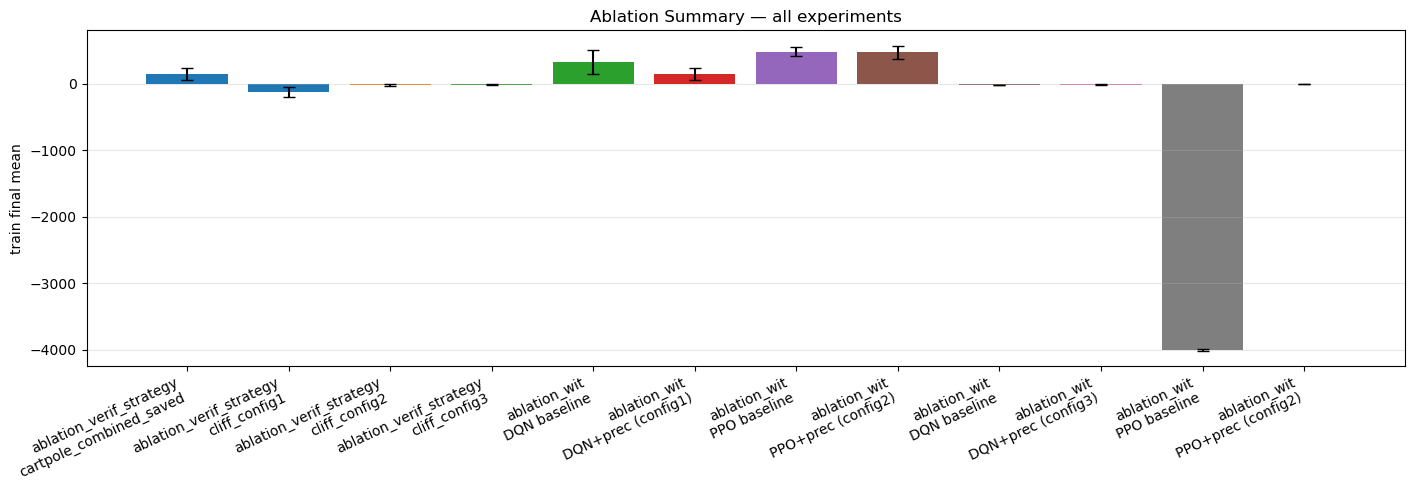

📊 /Users/nouhailanokry/Desktop/REINFORCEMENT LEARNING/Projet/PHASE 5: ABLATION STUDY/plots/ablation_summary_all.png


In [4]:
# Bar chart global — toutes les expériences avec train_final_mean
entries = []
for name, data in all_res.items():
    if name == "ablation_with_vs_without" and "entries" in data:
        for e in data["entries"]:
            e2 = dict(e)
            e2["label"] = f"{name[:12]}\n{e.get('label','')[:20]}"
            entries.append(e2)
    elif isinstance(data, dict):
        for subk, subv in data.items():
            if isinstance(subv, dict) and "train_final_mean" in subv:
                entries.append({**subv, "label": f"{name}\n{subk}"})
            elif isinstance(subv, dict) and "final_mean" in subv:
                entries.append({"label": f"{name}\n{subk}", "train_final_mean": subv["final_mean"],
                                "train_final_std": subv["final_std"], "eval_mean": subv.get("eval_mean", 0)})

if entries:
    plot_bar_comparison(entries[:12], "Ablation Summary — all experiments", "ablation_summary_all.png")


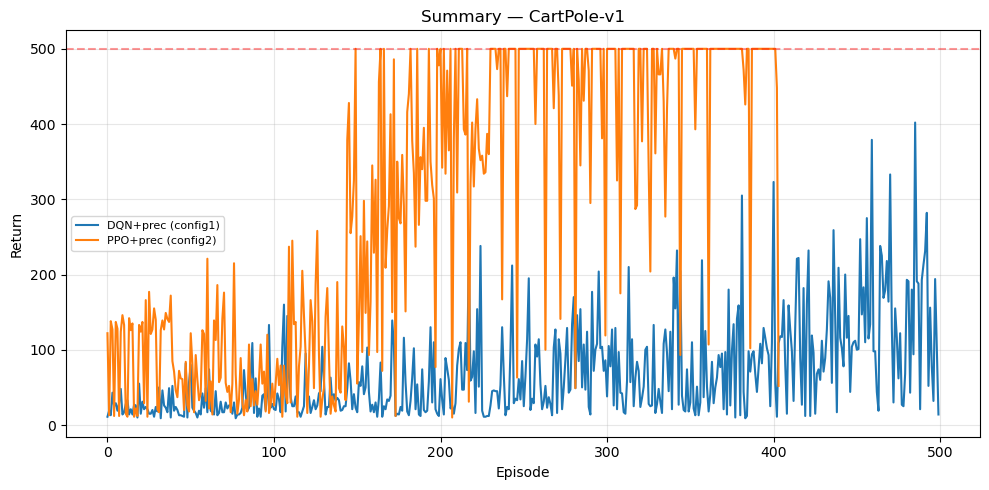

📊 /Users/nouhailanokry/Desktop/REINFORCEMENT LEARNING/Projet/PHASE 5: ABLATION STUDY/plots/ablation_summary_curves_CartPole_v1.png


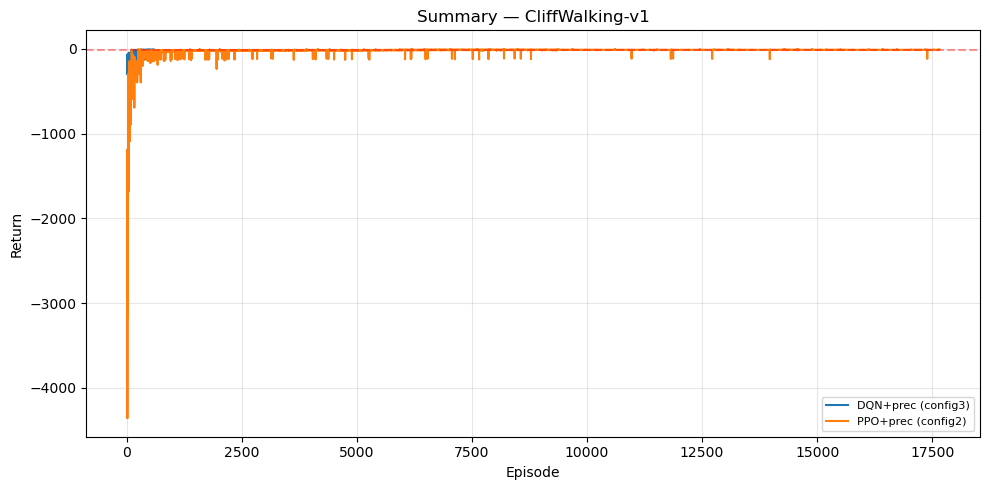

📊 /Users/nouhailanokry/Desktop/REINFORCEMENT LEARNING/Projet/PHASE 5: ABLATION STUDY/plots/ablation_summary_curves_CliffWalking_v1.png


In [5]:
# Superposer courbes principales (with vs without)
if "ablation_with_vs_without" in all_res:
    data = all_res["ablation_with_vs_without"]
    for env in ["CartPole-v1", "CliffWalking-v1"]:
        subset = [e for e in data.get("entries", []) if e.get("env_name") == env and e.get("rewards")]
        if subset:
            curves = {e["label"]: {"reward_curves": [e["rewards"]]} for e in subset}
            plot_learning_curves(curves, f"Summary — {env}", f"ablation_summary_curves_{env.replace('-','_')}.png",
                                 solve_threshold=ENV_SPECS[env]["solve_threshold"])
